In [107]:
import pandas as pd
import matplotlib.pyplot as plt
from features.Carl import (
           total_number_of_sessions_1,
           time_last_used_1,
           feature_total_pages_count_1,
           exact_device_type_1,
           num_status_1,
           gender_feature_ont_hot_1,
           location_state_one_hot_encoded_1,
           member_since_1,
           num_different_songs_1,
           num_different_artists_1)



from pipeline import create_X_y_df, create_1_week_X_y_df, create_2_week_X_y_df

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold, cross_val_predict
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report
from kaggle.api.kaggle_api_extended import KaggleApi

In [2]:
np.random.seed(42)

In [3]:
full_dataset_df = pd.read_parquet("../../../data/churn-prediction-25-26/train.parquet")

In [4]:
full_dataset_df.sample(10)

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,location,itemInSession,userAgent,method,length,song,artist,time,registration
8415245,200,M,August,paid,Clark,1207487,1540518498000,Logged In,NextSong,112798,"Riverside-San Bernardino-Ontario, CA",400,Mozilla/5.0 (Windows NT 6.1; Trident/7.0; rv:1...,PUT,236.04200,Hostile [Live Version],Pantera,2018-10-26 01:48:18,2018-09-10 17:03:47
12828473,200,F,Alani,paid,Kane,1325330,1541672419000,Logged In,NextSong,159518,"Tampa-St. Petersburg-Clearwater, FL",74,Mozilla/5.0 (Windows NT 6.1; rv:31.0) Gecko/20...,PUT,194.03710,Karibien,Air France,2018-11-08 10:20:19,2018-09-05 06:02:19
13490632,200,F,Angelina,paid,Singh,1495032,1541826321000,Logged In,NextSong,174513,"Santa Maria-Santa Barbara, CA",216,"""Mozilla/5.0 (iPhone; CPU iPhone OS 7_1_2 like...",PUT,278.07302,Through The Wire,Kanye West,2018-11-10 05:05:21,2018-08-24 13:24:27
9329450,200,M,Nathaniel,paid,Norris,1525270,1540794304000,Logged In,NextSong,128771,"San Francisco-Oakland-Hayward, CA",120,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,132.85832,Ride A White Swan,T. Rex,2018-10-29 06:25:04,2018-06-23 13:42:06
13901146,200,M,Landyn,paid,Evans,1849720,1541985370000,Logged In,NextSong,179047,"Atlanta-Sandy Springs-Roswell, GA",74,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,266.65751,Black Planet (Remastered),Sisters Of Mercy,2018-11-12 01:16:10,2018-08-25 21:44:42
930473,200,F,Alondra,paid,Johnson,1981365,1538601966000,Logged In,NextSong,35505,"Houston-The Woodlands-Sugar Land, TX",255,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.6; r...,PUT,579.83955,Kalopsia,Mark Otten,2018-10-03 21:26:06,2018-08-26 05:10:08
23244814,200,F,Georgia,paid,Walsh,1558947,1538958297000,Logged In,NextSong,7989,"Dallas-Fort Worth-Arlington, TX",12,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",PUT,201.79546,Revelry,Kings Of Leon,2018-10-08 00:24:57,2018-09-10 19:59:11
9200665,200,M,Jadon,paid,Benitez,1999781,1540750023000,Logged In,NextSong,132052,"San Diego-Carlsbad, CA",49,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; r...,PUT,98.14159,Samba De Una Nota SoÃÂ´,Joa~o Gilberto,2018-10-28 18:07:03,2018-08-31 02:26:28
5698983,200,F,Fatima,free,Hancock,1460110,1539845728000,Logged In,NextSong,74377,"New York-Newark-Jersey City, NY-NJ-PA",12,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,244.47955,Chana Masala,Looptroop,2018-10-18 06:55:28,2018-09-06 14:24:41
7062194,200,M,James,paid,Carlson,1588321,1540221175000,Logged In,NextSong,107607,"Cleveland-Elyria, OH",11,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:31....,PUT,218.27873,Tonight,FM Static,2018-10-22 15:12:55,2018-09-25 02:33:43


In [5]:
# Second Train Test set

#df_X, df_y = create_1_week_X_y_df(df = full_dataset_df)
df_X, df_y = create_2_week_X_y_df(df = full_dataset_df)

In [6]:
df_X["week_slice"].unique()

array([1, 2, 3])

In [7]:
def create_feature_engineered_df(df):
    feature_total_pages_count_df = feature_total_pages_count_1(df)
    total_number_of_sessions_df = total_number_of_sessions_1(df)
    time_last_used_df = time_last_used_1(df)
    num_status_df = num_status_1(df)
    device_type_df = exact_device_type_1(df)
    gender_feature_ont_hot_df = gender_feature_ont_hot_1(df)
    location_state_one_hot_encoded_df = location_state_one_hot_encoded_1(df)
    member_since_df = member_since_1(df)
    num_different_songs_df = num_different_songs_1(df)
    num_different_artists_df = num_different_artists_1(df)

    df = feature_total_pages_count_df.merge(total_number_of_sessions_df, on = ["userId", "week_slice"])
    df = df.merge(time_last_used_df, on = ["userId", "week_slice"])
    df = df.merge(num_status_df, on = ["userId", "week_slice"])
    df = df.merge(device_type_df, on = ["userId", "week_slice"])
    df = df.merge(gender_feature_ont_hot_df, on = ["userId", "week_slice"])
    df = df.merge(location_state_one_hot_encoded_df, on = ["userId", "week_slice"])
    df = df.merge(member_since_df, on = ["userId", "week_slice"])
    df = df.merge(num_different_songs_df, on = ["userId", "week_slice"])
    df = df.merge(num_different_artists_df, on = ["userId", "week_slice"])

    return df


df_X_features = create_feature_engineered_df(df_X)

/Users/aaron/Desktop/1_Studium/1_Master/1_Polytechnique/1_Courses/4_Python_for_Data_Science/2_Kaggle_Challenge/kaggle_challenge/src/features/Carl/device_used.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b.loc[:, "val"] = np.ones(len(df_b))


In [8]:
df_X_y = df_X_features.merge(df_y, on = ["userId", "week_slice"])

In [ ]:
columns_X = df_X_features.columns.drop(["userId"])
columns_y = ["Cancellation Confirmation", "week_slice"]

In [10]:
df_X_y["week_slice"].unique()

array([1, 2, 3])

In [11]:
df_X_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41394 entries, 0 to 41393
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   userId                     41394 non-null  object 
 1   week_slice                 41394 non-null  int64  
 2   About                      41394 non-null  float64
 3   Add Friend                 41394 non-null  float64
 4   Add to Playlist            41394 non-null  float64
 5   Downgrade                  41394 non-null  float64
 6   Error                      41394 non-null  float64
 7   Help                       41394 non-null  float64
 8   Home                       41394 non-null  float64
 9   Logout                     41394 non-null  float64
 10  NextSong                   41394 non-null  float64
 11  Roll Advert                41394 non-null  float64
 12  Save Settings              41394 non-null  float64
 13  Settings                   41394 non-null  flo

In [12]:
df_X_y["time_not_used"] = df_X_y["time_not_used"].apply(lambda x: x.total_seconds())

In [13]:
df_X_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41394 entries, 0 to 41393
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   userId                     41394 non-null  object 
 1   week_slice                 41394 non-null  int64  
 2   About                      41394 non-null  float64
 3   Add Friend                 41394 non-null  float64
 4   Add to Playlist            41394 non-null  float64
 5   Downgrade                  41394 non-null  float64
 6   Error                      41394 non-null  float64
 7   Help                       41394 non-null  float64
 8   Home                       41394 non-null  float64
 9   Logout                     41394 non-null  float64
 10  NextSong                   41394 non-null  float64
 11  Roll Advert                41394 non-null  float64
 12  Save Settings              41394 non-null  float64
 13  Settings                   41394 non-null  flo

In [14]:
df_X_y["gender"] = df_X_y["gender"].apply(lambda x: 1 if x else 0)

In [15]:
df_X_y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41394 entries, 0 to 41393
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   userId                     41394 non-null  object 
 1   week_slice                 41394 non-null  int64  
 2   About                      41394 non-null  float64
 3   Add Friend                 41394 non-null  float64
 4   Add to Playlist            41394 non-null  float64
 5   Downgrade                  41394 non-null  float64
 6   Error                      41394 non-null  float64
 7   Help                       41394 non-null  float64
 8   Home                       41394 non-null  float64
 9   Logout                     41394 non-null  float64
 10  NextSong                   41394 non-null  float64
 11  Roll Advert                41394 non-null  float64
 12  Save Settings              41394 non-null  float64
 13  Settings                   41394 non-null  flo

In [16]:
# Remove identifier column before scaling/modeling
X = df_X_y[columns_X]
y = df_X_y[columns_y]

#X_train, X_test, y_train, y_test = train_test_split(X, y)

X_train = X[X["week_slice"].isin([1, 3])]
X_test = X[X["week_slice"].isin([2])]

y_train = y[y["week_slice"].isin([1, 3])]
y_test = y[y["week_slice"].isin([2])]

In [17]:
X_train = X_train.drop(columns="week_slice")
X_test = X_test.drop(columns="week_slice")
y_train = y_train.drop(columns="week_slice")
y_test = y_test.drop(columns="week_slice")

In [18]:
y_train = y_train["Cancellation Confirmation"]
y_test = y_test["Cancellation Confirmation"]

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27690 entries, 0 to 41393
Data columns (total 82 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   About                     27690 non-null  float64
 1   Add Friend                27690 non-null  float64
 2   Add to Playlist           27690 non-null  float64
 3   Downgrade                 27690 non-null  float64
 4   Error                     27690 non-null  float64
 5   Help                      27690 non-null  float64
 6   Home                      27690 non-null  float64
 7   Logout                    27690 non-null  float64
 8   NextSong                  27690 non-null  float64
 9   Roll Advert               27690 non-null  float64
 10  Save Settings             27690 non-null  float64
 11  Settings                  27690 non-null  float64
 12  Submit Downgrade          27690 non-null  float64
 13  Submit Upgrade            27690 non-null  float64
 14  Thumbs Down

In [20]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).\
    columns.tolist()


categorical_columns = X_train.select_dtypes(include=["object"]).\
    columns.tolist()

preprocesseor_lr=ColumnTransformer(
    transformers=[
        ("numerical", StandardScaler(), num_cols),
        ("categorical", OneHotEncoder(), categorical_columns),
    ]
)

one_hot_dense_preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore",
                                 sparse_output=False),
                                 categorical_columns),
    ],
    remainder="passthrough"
)

model_lr = Pipeline([
    ("prepocesseor", preprocesseor_lr),
    ("model", LogisticRegression(max_iter=10000))#, class_weight={0:1, 1:10}))
])


model_hgbc = Pipeline([
    ("prepocesseor", one_hot_dense_preprocessor),
    ("model", HistGradientBoostingClassifier(max_depth=50))
])

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     12954
           1       0.00      0.00      0.00       750

    accuracy                           0.95     13704
   macro avg       0.47      0.50      0.49     13704
weighted avg       0.89      0.95      0.92     13704



/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aaron/anaconda3/envs/pfds/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

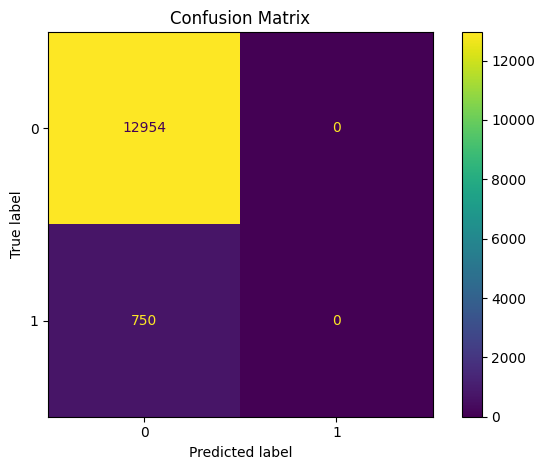

In [21]:
model_hgbc.fit(X_train, y_train)
pred = model_hgbc.predict(X_test)
print(classification_report(y_test, pred))

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()
#cross_validate(model_hgbc, X, y, return_train_score=True)


#https://scikit-learn.org/stable/modules/ensemble.html#interpretation-with-feature-importance

[[11990   964]
 [  605   145]]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     12954
           1       0.13      0.19      0.16       750

    accuracy                           0.89     13704
   macro avg       0.54      0.56      0.55     13704
weighted avg       0.91      0.89      0.90     13704



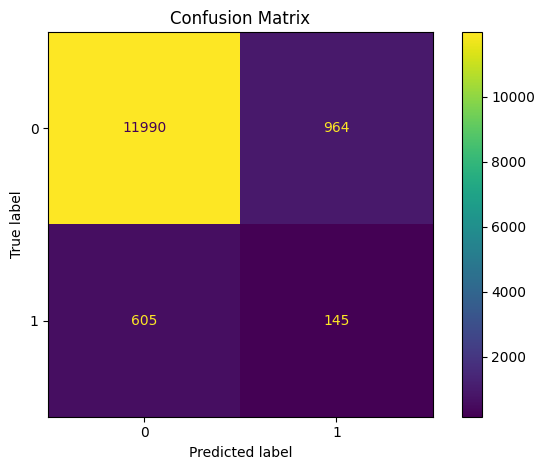

In [22]:


# 2) Preprocess: impute + one-hot for categoricals, impute for numerics
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))  # use sparse output by default
])

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_pipeline, categorical_columns),
        ("num", numeric_pipeline, num_cols),
    ],
    remainder="passthrough"
)

# 3) Model
xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"  # avoids warning in many setups
)


n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
spw = n_neg / max(n_pos, 1)

xgb = XGBClassifier(scale_pos_weight = spw)#, eval_metric="aucpr")
#xgb = XGBClassifier()

# 4) Full pipeline
clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", xgb)
])

clf.fit(X_train, y_train)
pred = clf.predict(X_test)

# numeric matrix
cm = confusion_matrix(y_test, pred)
print(cm)

print(classification_report(y_test, pred))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [24]:
df_test = pd.read_parquet("../../../data/churn-prediction-25-26/test.parquet")

In [64]:
df_test[pd.isna(df_test["registration"])]["userId"].unique()

# This user has weird behaviour

# 1261737
# 1261737
# 1261737
# 1261737
# 1261737

array([], dtype=object)

In [65]:
df_X_test, df_y_test = create_2_week_X_y_df(df = df_test)

In [68]:
df_X_test = df_X_test[~df_X_test["userId"].isin(["1261737"])]

In [69]:
df_X_test.sample(10)

,status,gender,firstName,level,lastName,userId,ts,auth,page,sessionId,...,itemInSession,userAgent,method,length,song,artist,time,registration,date,week_slice
997646,200,M,Nikolai,paid,Santos,1576041,1538618123000,Logged In,NextSong,39748,...,8,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,268.56444,OraciÃÂ³n Del Remanso,Liliana Herrero,2018-10-04 01:55:23,2018-09-14 03:55:22,2018-10-04,1
9727085,200,F,Kylie,paid,Woods,1562818,1540884687000,Logged In,NextSong,114341,...,214,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_4...",PUT,47.64689,Minus 3,Broadcast,2018-10-30 07:31:27,2018-08-25 02:45:57,2018-10-30,3
3997189,200,F,Kaziya,paid,Sutton,1416233,1539386078000,Logged In,NextSong,63083,...,5,Mozilla/5.0 (Windows NT 6.1; WOW64; rv:31.0) G...,PUT,292.59710,Hearts On Fire,Cut Copy,2018-10-12 23:14:38,2018-06-09 04:50:00,2018-10-12,1
7675063,200,F,Elizabeth,paid,Evans,1955639,1540355165000,Logged In,NextSong,112648,...,71,"""Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebK...",PUT,295.33995,The Whole World,Outkast Featuring Killer Mike,2018-10-24 04:26:05,2018-09-13 16:24:28,2018-10-24,2
2114224,200,M,Jordan,paid,James,1374536,1538948091000,Logged In,NextSong,46701,...,379,"""Mozilla/5.0 (Windows NT 6.3; WOW64) AppleWebK...",PUT,242.78159,To Be With You,Hoobastank,2018-10-07 21:34:51,2018-09-09 16:29:11,2018-10-07,1
24378183,200,F,Camila,paid,Collins,1441581,1540623035000,Logged In,Home,20635,...,0,"""Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/5...",GET,NaN,None,None,2018-10-27 06:50:35,2018-08-24 05:03:37,2018-10-27,2
2711065,200,M,Kendrick,paid,Mueller,1475401,1539097497000,Logged In,NextSong,58025,...,69,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:31....,PUT,90.98404,Boy's Life,Dr. Know,2018-10-09 15:04:57,2018-08-10 01:15:12,2018-10-09,1
372454,200,F,Amber,free,Snyder,1973177,1538461390000,Logged In,NextSong,25641,...,27,"""Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3...",PUT,223.55546,Had Enough,Lifehouse,2018-10-02 06:23:10,2018-09-26 12:19:11,2018-10-02,1
11943367,200,F,Madilynn,paid,Curry,1407086,1541463357000,Logged In,Home,159557,...,5,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.9; r...,GET,NaN,None,None,2018-11-06 00:15:57,2018-09-27 14:59:32,2018-11-06,3
6286135,200,F,Lindsey,paid,Gaines,1715596,1539973150000,Logged In,NextSong,93171,...,22,"""Mozilla/5.0 (Windows NT 6.1) AppleWebKit/537....",PUT,208.92689,Girl In The Life Magazine,Boyz II Men,2018-10-19 18:19:10,2018-09-20 11:56:57,2018-10-19,2


In [70]:
df_X_test_features = create_feature_engineered_df(df_X_test)

/Users/aaron/Desktop/1_Studium/1_Master/1_Polytechnique/1_Courses/4_Python_for_Data_Science/2_Kaggle_Challenge/kaggle_challenge/src/features/Carl/device_used.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_b.loc[:, "val"] = np.ones(len(df_b))


In [80]:
df_X_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41394 entries, 0 to 41393
Data columns (total 84 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   userId                    41394 non-null  object 
 1   week_slice                41394 non-null  int64  
 2   About                     41394 non-null  float64
 3   Add Friend                41394 non-null  float64
 4   Add to Playlist           41394 non-null  float64
 5   Downgrade                 41394 non-null  float64
 6   Error                     41394 non-null  float64
 7   Help                      41394 non-null  float64
 8   Home                      41394 non-null  float64
 9   Logout                    41394 non-null  float64
 10  NextSong                  41394 non-null  float64
 11  Roll Advert               41394 non-null  float64
 12  Save Settings             41394 non-null  float64
 13  Settings                  41394 non-null  float64
 14  Submit

In [71]:
columns_X_test = df_X_test_features.columns.drop(["userId"])

In [73]:
df_X_test_features["time_not_used"] = df_X_test_features["time_not_used"].apply(lambda x: x.total_seconds())

In [74]:
# Remove identifier column before scaling/modeling
X = df_X_test_features[columns_X_test]
y = df_X_test_features[columns_X_test]

#X_train, X_test, y_train, y_test = train_test_split(X, y)

#X_train = X[X["week_slice"].isin([1, 3])]
#X_test = X[X["week_slice"].isin([2])]

#y_train = y[y["week_slice"].isin([1, 3])]
#y_test = y[y["week_slice"].isin([2])]

In [75]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7900 entries, 0 to 7899
Data columns (total 83 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   week_slice                7900 non-null   int64  
 1   About                     7900 non-null   float64
 2   Add Friend                7900 non-null   float64
 3   Add to Playlist           7900 non-null   float64
 4   Downgrade                 7900 non-null   float64
 5   Error                     7900 non-null   float64
 6   Help                      7900 non-null   float64
 7   Home                      7900 non-null   float64
 8   Logout                    7900 non-null   float64
 9   NextSong                  7900 non-null   float64
 10  Roll Advert               7900 non-null   float64
 11  Save Settings             7900 non-null   float64
 12  Settings                  7900 non-null   float64
 13  Submit Downgrade          7900 non-null   float64
 14  Submit U

In [88]:
X_pred_submission = X[X["week_slice"].isin([3])]

In [89]:
X_pred_submission.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2647 entries, 2 to 7899
Data columns (total 83 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   week_slice                2647 non-null   int64  
 1   About                     2647 non-null   float64
 2   Add Friend                2647 non-null   float64
 3   Add to Playlist           2647 non-null   float64
 4   Downgrade                 2647 non-null   float64
 5   Error                     2647 non-null   float64
 6   Help                      2647 non-null   float64
 7   Home                      2647 non-null   float64
 8   Logout                    2647 non-null   float64
 9   NextSong                  2647 non-null   float64
 10  Roll Advert               2647 non-null   float64
 11  Save Settings             2647 non-null   float64
 12  Settings                  2647 non-null   float64
 13  Submit Downgrade          2647 non-null   float64
 14  Submit Upgrad

In [86]:
df_test_userId_set = set(df_test["userId"].unique())
df_2_week_userId_set = set(df_X_test_features[df_X_test_features["week_slice"] == 3]["userId"].unique())

In [97]:
churn_submission_prediction = clf.predict(X_pred_submission)

In [101]:
type(churn_submission_prediction)

numpy.ndarray

In [139]:
result = pd.DataFrame(data={
    "id": df_X_test_features[df_X_test_features["week_slice"] == 3]["userId"],
    "target" : churn_submission_prediction
})

In [140]:
result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2647 entries, 2 to 7899
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2647 non-null   object
 1   target  2647 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 62.0+ KB


In [141]:
def kaggle_submit(competition: str, file_path: str, message: str = "submission"):
    api = KaggleApi()
    api.authenticate()
    # Signature: competition_submit(file_name, message, competition, quiet=False)
    api.competition_submit(file_path, message, competition)

In [157]:
already_churned = pd.DataFrame(
    data = {
        "id" : df_test[~df_test["userId"].isin(result["id"])]["userId"].unique(),
        "target" : np.ones(len(df_test[~df_test["userId"].isin(result["id"])]["userId"].unique()))
    }
)

In [158]:
len(already_churned)

257

In [159]:
combined_result = pd.concat([result, already_churned], axis = 0)

In [160]:
combined_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2904 entries, 2 to 256
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2904 non-null   object 
 1   target  2904 non-null   float64
dtypes: float64(1), object(1)
memory usage: 68.1+ KB


In [161]:
combined_result["target"] = combined_result["target"].astype(int)

In [163]:
combined_result.to_csv("2_week_window.csv", index = False)

In [164]:
combined_result["target"].mean()

np.float64(0.14634986225895316)